#Demo de Alpha Zero (AZ) para aprender a jugar al Ta-Te-Ti

Basado en:

https://github.com/suragnair/alpha-zero-general
https://github.com/AppliedDataSciencePartners/DeepReinforcementLearning/blob/master/model.py

con cambios para compatibilidad con TF-keras 3, y facilitar el entendimiento del código.

La explicación se puede encontrar en https://pathtopioneer.com/blog/2020/07/rl-6  y/o  https://medium.com/applied-data-science/how-to-build-your-own-alphazero-ai-using-python-and-keras-7f664945c188

En esta nueva versión se hace compatible con Gymnasium: https://gymnasium.farama.org/



In [1]:
#@title Cargar Librerías

import argparse
import os
import shutil
import time
import random
import numpy as np
import math
from matplotlib import pyplot as plt

from collections import deque
from pickle import Pickler, Unpickler
from tqdm import tqdm

import tensorflow as tf

from typing import Optional
import gymnasium as gym

print("Librerías cargadas.")

Librerías cargadas.


## Clases sobre el Problema a resolver

In [2]:
#@title Definir clase auxiliar Tablero Ta-Te-Ti


# define el tablero del juego
class TTTBoard():

    # define colores de piezas en tablero
    player_X = -1
    player_O = 1

    def __init__(self, n=3, obs=None):
        if obs is None:
          # define tamaño del tablero y lo genera
          self.n = n
          self.reset()
        else:
          # genera tablero en base a observación
          obsAux = np.array(obs).flatten()
          self.n = int(math.sqrt(len(obsAux)))
          assert (self.n**2==len(obsAux))
          self.pieces = obsAux.reshape((self.n, self.n))

    # crea tablero vacío
    def reset(self):
        self.pieces = [None]*self.n
        for i in range(self.n):
            self.pieces[i] = [0]*self.n

    # indexer [][] para obtner todas las piezas del tablero
    def __getitem__(self, index):
        return self.pieces[index]

    # devuelve nombre jugador
    @staticmethod
    def getPlayerName(player):
      if player==TTTBoard.player_X:
        return "X"
      elif player==TTTBoard.player_O:
        return "O"
      else:
        return "?"

    # controla movimientos válidos y devuelve el primero o todos
    def __checkLegalMoves(self, returnFirst=False):
        # inicializa
        moves = []
        # devuelve todas las coordenadas sin valores
        for y in range(self.n):
            for x in range(self.n):
                if self[x][y]==0:
                    newmove = (x+1,y+1)
                    moves.append(newmove)
                    # si es solicitado devuelve primero
                    if returnFirst:
                      return moves
        return moves

    # devuelve todos los movimientos válidos que puede hacer un color
    def getLegalMoves(self):
      return self.__checkLegalMoves(returnFirst=False)

    # devuelve si hay algún movimiento válido para hacer
    def hasLegalMoves(self):
      validMoves = self.__checkLegalMoves(returnFirst=True)
      return len(validMoves)>0

    # pone una pieza del player correspondiente en el tablero
    # devuelve Verdadero si se pudo hacer, sino Falso
    def executeMovePlayer(self, move, player):
        # la posición
        (x,y) = move
        # ajusta posición
        x = x-1
        y = y-1
        # controla que sea una posición válida
        if (x>=0) and (x<self.n) and (y>=0) and (y<self.n):
          # controla que la posiciń este vacía
          if self[x][y] == 0:
            # controla que sea un jugador válido
            if player==self.player_X or player==self.player_O:
              # ubica la pieza
              self[x][y] = player
              return True
        return False

    # determina si un player gano por tener todas iguales en alguna dirección
    def hasPlayerWin(self, player):
        # cantidad para ganar
        win = self.n
        # control en el eje Y
        for y in range(self.n):
            count = 0
            for x in range(self.n):
                if self[x][y]==player:
                    count += 1
            if count==win:
                return True
        # controla en el eje X
        for x in range(self.n):
            count = 0
            for y in range(self.n):
                if self[x][y]==player:
                    count += 1
            if count==win:
                return True
        # controla las diagonales
        count = 0
        for d in range(self.n):
            if self[d][d]==player:
                count += 1
        if count==win:
            return True
        count = 0
        for d in range(self.n):
            if self[d][self.n-d-1]==player:
                count += 1
        if count==win:
            return True
        return False

    # determina si está en estado final del juego
    # y si es así quién gano o si hay empate
    def hasEnd(self):
        # determina si algún jugador ganó
        # y devuelve el ID que corresponde
        if self.hasPlayerWin(self.player_X):
            return True, self.player_X
        elif self.hasPlayerWin(self.player_O):
            return True, self.player_O
        # se fija si hay movimentos válidos
        elif self.hasLegalMoves():
            return False, None
        else:
          # para empate se devuelve cero en jugador
          # y un reward intermedio
          return True, 0

    # cambia signo dependiendo signo de jugador
    def getCanonicalForm(self, player=1):
        return (player*self.toMatrix())

    # devuelve la situación del tablero como array
    def toMatrix(self):
        return np.array(self.pieces)

    # muestra la situación del tablero
    def render(self, display=True):
        # inicializa varaibles auxilires
        sangria = "     "
        textoRender = ""
        # genera cabecera de recuadro
        textoRender += sangria + " "
        for _ in range(self.n+1):
            textoRender += "--"
        textoRender += "\n"
        # muestra situación del tablero
        for y in range(self.n):
            textoRender += sangria + str(y+1) + "|"
            for x in range(self.n):
                piece = self.pieces[x][y]
                if piece == self.player_X:
                  textoRender += "X"
                elif piece == self.player_O:
                  textoRender += "O"
                else:
                    textoRender += "-"
                if y<self.n:
                  textoRender += " "
            textoRender += "|\n"
        # genera pie de recuadro
        textoRender += sangria + " "
        for _ in range(self.n+1):
            textoRender += "--"
        textoRender += "\n"
        textoRender += sangria + "  "
        for y in range(self.n):
            textoRender += str(y+1) + " "
        textoRender += "\n"
        if display:
          print(textoRender)
        return textoRender

print("Clase auxiliar TTTBoard definida.")

Clase auxiliar TTTBoard definida.


In [3]:
#@title Definir Entorno del Juego Ta-Te-Ti

# máxim iteraciones por juego
maxima_cantidad_iteraccines_por_juego = 9

# Entorno para el juego con 2 jugadores
class TTTGameEnv(gym.Env):

  # indica si observation es un vector o matriz
  usar_observacion_como_vector = True

  def __init__(self, board_n:int=3, max_iter:int=9):
    # determina tamaño tablero
    if board_n<2:
      raise ValueError('Tamaño del tablero inválido:' + str(board_n))
    self._board_n = board_n
    # máxima cantidad de iteracciones (por cada jugador)
    self._max_iter = max(max_iter, 10)*2
    # las acciones
    self.action_space = gym.spaces.Discrete(self._getActionSize())
    # la observación es el estado actual de la máquina
    if self.usar_observacion_como_vector:
      # usa observación como vector
      self.observation_space = gym.spaces.Box(low=-1, high=1, shape=(self._board_n**2, ), dtype=np.int64)
    else:
      # usa observación como matriz
      self.observation_space = gym.spaces.Box(low=-1, high=1, shape=(self._board_n, self._board_n ), dtype=np.int64)
    # resetea el entorno
    self.reset()

  # métodos estáticas para registración del modelo
  @staticmethod
  def getEnvID():
    return "demoRL/TTTGameEnv-v1"

  @staticmethod
  def getEnvNonDeterministic():
    return False

  # función auxiliar para convertir una acción numérica a posición para mover
  def _convertActionToMove(self, action):
    return (int(action/self._board_n)+1, int(action%self._board_n)+1)

  #  devuelve cantidad máxima de acciones que se pueden realizar
  def _getActionSize(self):
    return self._board_n**2

  # función auxiliar para convertir observación en tablero del juego
  # se usa para poder simular jugadas con AlphaZero
  @staticmethod
  def convertObsToBoard(obs, player=1):
    auxObs = obs*player
    return TTTBoard(obs=auxObs)

  # función auxiliar para convertir tablero del juego a observación
  # se usa para poder simular jugadas con AlphaZero
  @staticmethod
  def convertBoardToObs(board, player=1):
    auxBoard = board.toMatrix()*player
    auxBoard = auxBoard
    if TTTGameEnv.usar_observacion_como_vector:
      # usa observación como vector
      return auxBoard.flatten()
    else:
      # usa observación como matriz
      return auxBoard

  # devuelve la observación del estado actual del tablero para el jugador actual
  def _get_obs(self):
    if (self._lastPlayerId is not None) and (self._lastPlayerId!=0):
      return self.convertBoardToObs(self._board, self._lastPlayerId)
    else:
      return self.convertBoardToObs(self._board)

  # devuelve información adicional sobre el estado actual
  def _get_info(self):
    auxInfo = { }
    auxInfo["boardState"] = self._board.toMatrix()
    auxInfo["reward"] = self._reward
    auxInfo["episodeTerminated"] = self._episodeTerminated
    auxInfo["episodeTruncated"] = self._episodeTruncated
    auxInfo["cantIteraciones"] = self._cantIteraciones
    auxInfo["lastPlayerId"] = self._lastPlayerId
    if self._lastPlayerId is None:
      auxInfo["lastPlayerName"] = None
    else:
      auxInfo["lastPlayerName"] = "jugador " + self._board.getPlayerName(self._lastPlayerId)
    auxInfo["lastActionId"] = self._lastActionId
    if self._lastActionId is None:
      auxInfo["lastActionMove"] = None
    else:
      auxInfo["lastActionMove"] = self._lastActionMove
    auxInfo["resAction"] = self._lastResAction
    auxInfo["winnerId"] = self._winnerId
    auxInfo["penalPlayers"] = self._penalPlayers
    auxInfo["nextPlayerId"] = self.getNextPlayerId()
    auxInfo["nextPlayerName"] = "jugador " + self._board.getPlayerName(auxInfo["nextPlayerId"])
    #auxInfo["boardRender"] = self._board.render(display=False)
    return auxInfo

  # determina el id del jugador (X o O) de la próxima jugada
  # pero no lo cambia todavía
  def getNextPlayerId(self):
    # siempre arranca X
    if self._lastPlayerId is None:
      return TTTBoard.player_X
    # cambia jugador en base a último que jugó
    elif self._lastPlayerId == TTTBoard.player_O:
      return TTTBoard.player_X
    else:
      return TTTBoard.player_O

  # cambia id del jugador (X o O) y lo devuelve
  def _changePlayerId(self):
    # actualiza id
    self._lastPlayerId = self.getNextPlayerId()
    # devuelve nuevo
    return self._lastPlayerId

  # resetea el entorno
  def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
    #super().reset(seed=seed)
    # crea nuevo tablero
    self._board = TTTBoard(self._board_n)
    self._cantIteraciones = 0
    self._episodeTerminated = False
    self._episodeTruncated = False
    self._reward = 0.0
    self._lastPlayerId =  None
    self._lastActionId = None
    self._lastActionMove = None
    self._winnerId = None
    self._lastResAction = None
    self._penalPlayers = {}
    # devuelve observación e info actual
    self._lastObs = self._get_obs()
    self._lastInfo = self._get_info()
    return self._lastObs, self._lastInfo

  # aplicaca la acción del jugador en el entorno
  def step(self, action):
    # determina información de la jugada
    self._lastActionId = action
    self._lastPlayerId = self._changePlayerId()
    # determina estado del tablero
    self._episodeTerminated, self._winnerId  = self._board.hasEnd()
    # si no terminó el juego
    if not self._episodeTerminated:
      # actualiza cantidad de iteraciones
      self._cantIteraciones += 1
      # si se supera el máximo, cancela la acción y finaliza truncada
      if self._cantIteraciones >= self._max_iter:
        self._episodeTruncated = True
      else:
        # aplica la acción en el tablero
        self._lastActionMove = self._convertActionToMove(self._lastActionId)
        self._lastResAction = self._board.executeMovePlayer(self._lastActionMove, self._lastPlayerId)
        if self._lastResAction:
          # determina el nuevo estado del tablero
          self._episodeTerminated, self._winnerId = self._board.hasEnd()
        else:
          # si el movimiento no fue válido
          if self._lastPlayerId not in self._penalPlayers:
            self._penalPlayers [self._lastPlayerId] = 0
          self._penalPlayers [self._lastPlayerId] += 1
    # calcula reward si corresponde
    if self._episodeTruncated or self._episodeTerminated:
      # si se forzó la finalización
      if self._episodeTruncated:
        # penaliza reward
        self._reward = 0.0
      else: # si terminó el juego (estado original o nuevo)
        # si termina determina si es el ganador
        if self._winnerId == 0:
          # es empate
          self._reward = 1e-4
        elif self._lastPlayerId == self._winnerId:
          # ganó el jugador actual
          self._reward = 1.0
        else:
          # ganó el otro jugador
          self._reward = -1.0
      # le agrega penalización por malas jugadas si corresponde
      if self._lastPlayerId in self._penalPlayers:
        self._reward -= self._penalPlayers[self._lastPlayerId]/100.0
    else:
      self._reward = 0.0
    # devuelve observación e info actual
    self._lastObs = self._get_obs()
    self._lastInfo = self._get_info()
    return self._lastObs, self._reward, self._episodeTerminated, self._episodeTruncated, self._lastInfo

  # muestra la situación actual del entrono
  def render(self, showPlay=True):
    textoRender = ""
    if showPlay:
      if self._cantIteraciones==0:
        sitEpisode = "Ini"
      else:
        sitEpisode = "#"+str(abs(self._cantIteraciones))
      # muestra información
      textoRender += " " + sitEpisode + ": "
      if (self._lastInfo is not None):
        if self._lastInfo["lastPlayerName"] is not None:
          textoRender +=  self._lastInfo["lastPlayerName"]
        if self._lastInfo["lastActionMove"] is not None:
          textoRender += ": " + str(self._lastInfo["lastActionMove"])
        if (self._lastInfo["resAction"] is not None) and (self._lastInfo["resAction"]==False):
          textoRender += " INVÁLIDA! "
    ## textoRender += "\n\n" + self._board.render(display=False) + "\n"
    if self._episodeTerminated or self._episodeTruncated:
      textoRender += "\n -Situación Final: "
      textoRender += "\n\n" + self._board.render(display=False) + "\n"
      if self._episodeTruncated:
        textoRender += "    FINALIZACIÓN FORZADA"
        if self._lastInfo["cantIteraciones"] is not None:
          textoRender +=  " (cant.int. " + str(self._lastInfo["cantIteraciones"]) + ")"
      elif self._winnerId == 0:
        textoRender += "    EMPATE "
      elif self._lastInfo["winnerId"] is not None:
        textoRender += "    GANA jugador " + self._board.getPlayerName(self._lastInfo["winnerId"])
      else:
        textoRender += "    GANA " + str(self._lastInfo["winnerId"])
      textoRender += "\n"
    print(textoRender)
    return textoRender


# registra el entorno
gym.register(
    id = TTTGameEnv.getEnvID(),
    entry_point = TTTGameEnv,
    nondeterministic = TTTGameEnv.getEnvNonDeterministic())

# Inicializa el entorno de entrenamiento y evaluación
envProblema = gym.make( TTTGameEnv.getEnvID(),
                       board_n = 3,
                       max_iter = maxima_cantidad_iteraccines_por_juego)


print("Entorno del Problema definido.")

# Clase para Agente que juega al azar
# lo único que considera son las posibles acciones a realizar
# para elegir una al azar
class RandomAgentClass():

  def __init__(self, observation_space, action_space):
    self._action_space = action_space

  def action(self, observation=None, info=None):
      # devuelve una acción al azar
      return self._action_space.sample()

randomAgent = RandomAgentClass(envProblema.observation_space,
                                                envProblema.action_space)

print("Agente Random definido para el entorno. ")

# Clase para Agente Humano
class HumanAgentTTTClass():

  def __init__(self, observation_space, action_space):
    self._action_space = action_space
    self._n = math.sqrt(action_space.n)

  def action(self, observation, info=None):
      while True:
          # determina player id
          if (info is None) or ("nextPlayerId" not in info) or (info["nextPlayerId"] is None):
            # asume que es el primer jugador
            playerId = -1
            playerName = ""
          else:
            # lo obtiene de info
            playerId = info["nextPlayerId"]
            playerName = info["nextPlayerName"]
          # muestra estado del tablero en base a obs
          TTTGameEnv.convertObsToBoard(observation).render(display=True)
          # solicita nuevo movimiento
          e = input("Indique la coordenada para " + playerName + ": ")
          e = e.strip()
          x, y = -1, -1
          # identifica separador
          strSep = None
          for auxSep in [' ', ',', ';', '.']:
            if e.find(auxSep) > 0:
              strSep = auxSep
              break
          # obtiene coordenadas
          if strSep is None:
            if len(e)==2:
              vals = [int(e[0]), int(e[1])]
            else:
              print('Coordenada x,y inválida!')
          else:
            vals = [int(v) for v in e.split(strSep)]
            if len(vals)!=2:
              print('Coordenada x,y inválida!')
          # obtiene valores
          x, y = vals
          # controla posiciones y si está OK devuelve la acción
          if (x<=0) or (y<=0) or (x>self._n) or (y>self._n):
              print('Coordenada x,y inválida!')
          else:
              a = self._n * (x-1) + (y-1)
              return a

# genera agente humano para TTT
humanoAgent = HumanAgentTTTClass(envProblema.observation_space, envProblema.action_space)


print("Agente Humano definido para el entorno. ")


# funciones auxiliares para simular la ejecución del entorno

# intentar pasar los wrappers de gym para llegar
# al entorno del problema específico
def getEntornoProblema(env, envName):
  envAuxi = env
  for i in range(10):
    if envName in str(type(envAuxi)):
      return envAuxi
    elif hasattr(envAuxi, "env"):
      envAuxi = envAuxi.env
    else:
      return None

def mostrarObsInfoStep(env_obs, env_info, action_step=None):
  print("\t", end=" ")
  if action_step is not None:
    print("action_step {}".format(action_step), end=" -> ")
  print("env obs {} & info {}".format(env_obs, env_info))

# definir simulador para probar el entorno
def SimularEntorno(env, ag1, ag2, titulo="", mostrarRender=True, mostrarResultado=True, mostarInfoStep=False) :
    if len(titulo)>0:
      print("\n** ", titulo, "**")
    # inicializa variables
    done = False
    playerList = [ag1, ag2]
    # resetea el entorno
    env_obs, env_info  = env.reset()
    if mostrarRender:
      env.render()
      if mostarInfoStep:
        mostrarObsInfoStep(env_obs, env_info)
    while not done:
      for playerAg in playerList:
        # el agente determina la acción a realizar
        action_step = playerAg.action(env_obs, env_info)
        # se ejecuta la acción en el entorno
        env_obs, env_reward, env_terminated, env_truncated, env_info =  env.step(action_step)
        if mostrarRender:
          env.render()
          if mostarInfoStep:
            mostrarObsInfoStep(env_obs, env_info, action_step)
        # determina si finaliza la simulación
        done = env_terminated or env_truncated
        if done:
          break
    if mostrarResultado:
      if not mostrarRender:
        # para pasarle el parámetro se debe pasar por 2 wrappers
        envGame = getEntornoProblema(env, "TTTGameEnv")
        if envGame is None:
          env.render()
        else:
          envGame.render(showPlay=False)
    # determina ganador
    if env_truncated:
      # corte forzado, ambos pierden
      resultado = [ 0, 0, 0]
    if env_info["winnerId"] == TTTBoard.player_X:
      # gana 1ro Ag: X
      resultado = [ 1, 0, 0]
    elif env_info["winnerId"] == TTTBoard.player_O:
      # gana 2do Ag: O
      resultado = [ 0, 1, 0]
    else:
      # empate
      resultado = [ 0, 0, 1]
    return resultado

# función auxiliar para comparar
def CompetirAgentes(cantidad_probar, ag1, ag2, descAg1="Agente 1", descAg2="Agente 2", mostrar=True, mostrarResultadoJugadas=False):
  cantGanados = [0.0, 0.0, 0.0]
  if isinstance(ag1, HumanAgentTTTClass) or isinstance(ag2, HumanAgentTTTClass):
      # simula jugada contra humano
      resultado = SimularEntorno(envProblema, ag1, ag2, "   Compiten " + descAg1 + " (X) vs " + descAg2 +" (O):", mostrarRender=True, mostrarResultado=True, mostarInfoStep=False)
      cantGanados[0] += resultado[0]
      cantGanados[1] += resultado[1]
      cantGanados[2] += resultado[2]
  else:
      mitad_cantidad_probar = int(cantidad_probar / 2)
      if not mostrar:
        mostrarResultadoJugadas = False
      # simular entorno mitad y mitad para jugadores
      if mitad_cantidad_probar == 0:
        mitad_cantidad_probar = 1
      for i in tqdm(range(mitad_cantidad_probar), desc="   Compiten " + descAg1 + " (X) vs " + descAg2 + " (O)"):
          # primero ag1 y luego ag2
          resultado = SimularEntorno(envProblema, ag1, ag2, titulo="", mostrarRender=False, mostrarResultado=mostrarResultadoJugadas, mostarInfoStep=False)
          cantGanados[0] += resultado[0]
          cantGanados[1] += resultado[1]
          cantGanados[2] += resultado[2]
      for i in tqdm(range(mitad_cantidad_probar), desc="   Compiten " + descAg2 + " (X) vs " + descAg1 + " (O)"):
          # primero ag2 y luego ag1
          resultado = SimularEntorno(envProblema, ag2, ag1, titulo="", mostrarRender=False, mostrarResultado=mostrarResultadoJugadas, mostarInfoStep=False)
          cantGanados[0] += resultado[1]
          cantGanados[1] += resultado[0]
          cantGanados[2] += resultado[2]
  # Decide Ganador General
  if mostrar and (cantidad_probar > 0):
    posMax = np.argmax(cantGanados)
    print("\n================================================================================================\n")
    print(" -- " + descAg1 + " gana: " + str(round(cantGanados[0], 1) ) + " " + ("*" if posMax==0 else ""))
    print(" -- " + descAg2 + " gana: " + str(round(cantGanados[1], 1) ) + " " + ("*" if posMax==1 else ""))
    print(" -- cantidad de empates: " + str(round(cantGanados[2], 1) ) + " " + ("*" if posMax==2 else ""))
    print("\n================================================================================================\n")
  return cantGanados


print("Simulador del entorno definido.")

# Probar el entorno definido con Política Aleatoria (opcional)
Probar_Entorno_Random = True #@param {type:"boolean"}
Probar_Entorno_con_Humano = False #@param {type:"boolean"}
MostarDetalleSteps = False #@param {type:"boolean"}

if Probar_Entorno_Random:
  SimularEntorno(envProblema, randomAgent, randomAgent, "Probando el entorno del problema al Azar", mostrarRender=True, mostarInfoStep=MostarDetalleSteps)
print("")

if Probar_Entorno_con_Humano:
    SimularEntorno(envProblema, humanoAgent, randomAgent, "Probando el entorno del problema Humano vs Azar", mostrarRender=True, mostarInfoStep=MostarDetalleSteps)



Entorno del Problema definido.
Agente Random definido para el entorno. 
Agente Humano definido para el entorno. 
Simulador del entorno definido.

**  Probando el entorno del problema al Azar **
 Ini: 
 #1: jugador X: (1, 1)
 #2: jugador O: (2, 2)
 #3: jugador X: (3, 2)
 #4: jugador O: (3, 2) INVÁLIDA! 
 #5: jugador X: (2, 3)
 #6: jugador O: (2, 2) INVÁLIDA! 
 #7: jugador X: (1, 1) INVÁLIDA! 
 #8: jugador O: (1, 1) INVÁLIDA! 
 #9: jugador X: (1, 3)
 #10: jugador O: (1, 3) INVÁLIDA! 
 #11: jugador X: (3, 1)
 #12: jugador O: (3, 3)
 #13: jugador X: (1, 3) INVÁLIDA! 
 #14: jugador O: (2, 3) INVÁLIDA! 
 #15: jugador X: (1, 1) INVÁLIDA! 
 #16: jugador O: (1, 3) INVÁLIDA! 
 #17: jugador X: (1, 1) INVÁLIDA! 
 #18: jugador O: (2, 1)
 #19: jugador X: (1, 1) INVÁLIDA! 
 #20: jugador O: (1, 1) INVÁLIDA! 
 -Situación Final: 

      --------
     1|X O X |
     2|- O X |
     3|X X O |
      --------
       1 2 3 

    FINALIZACIÓN FORZADA (cant.int. 20)




In [4]:
#@title Wrapper para usar Entorno durante Entrenamiento con un Agente

jugar_contra = "Self-Play" #@param ["Self-Play", "Azar"]

generar_info_QL = False #@param{type:"boolean"}

# clase auxiliar para simular jugadas (usado por MCTS de AZ)
class TTTGameSimulator():

  # inicializa
  def __init__(self, board=None):
    self.board = board

  # crea un nuevo tablero en base una observación actual
  def createNewBoard(self, obs, player=1):
    self.board = TTTGameEnv.convertObsToBoard(obs, player)

  # determina observación en base a tablero actual
  def convertToObs(self, player=1):
    assert self.board is not None, "Tablero no definido!"
    return TTTGameEnv.convertBoardToObs(self.board, player)

  # determina acciones válidas para el estado
  # del tablero actual simulado
  def getValidActions(self, num_actions=None):
    assert self.board is not None, "Tablero no definido!"
    # determina movimientos válidos
    legalMoves = self.board.getLegalMoves()
    # devuelve acciones válidas
    if num_actions is None:
      valids = [0] * self.board.n
    else:
      valids = [0] * num_actions
    #if len(legalMoves)==0:
    #    valids[-1]=1
    #    return np.array(valids)
    for x, y in legalMoves:
        x-=1
        y-=1
        valids[self.board.n*x+y]=1
    return np.array(valids)

  # simula nuevo estado del tablero por realizar una acción
  def getNextState(self, player, action):
    assert self.board is not None, "Tablero no definido!"
    move = (int(action/self.board.n)+1, action%self.board.n+1)
    self.board.executeMovePlayer(move, player)
    return (self.convertToObs(), -player)

  # determina si el juego simulado está en estado final
  # y en ese caso indica quién ganó o empate
  def hasEndReward(self, player):
    assert self.board is not None, "Tablero no definido!"
    resEnd, winnerId = self.board.hasEnd()
    if resEnd:
      # si terminó
      if winnerId == 0:
        # es empate
        return 1e-4
      else:
        # determina si tiene que mantener o no signo
        # dependiendo del jugador actual
        if player==winnerId:
          return 1.0
        else:
          return -1.0
    else:
      # si no terminó
      return 0


# clase auxiliar wrapper para poder entrenar con un sólo jugador
class TTTGameEnvTrainingWrapper():

  def __init__(self, env, player2Ag):
    self._env = env
    self._agPlayer2 = player2Ag
    # intenta obtener tamaño tablero
    self._envTTT = getEntornoProblema(env, "TTTGameEnv")
    if self._envTTT is None:
      self._board_n = self._envTTT._board_n
    else:
      self._board_n = 3

  @property
  def action_space(self):
    return self._env.action_space

  @property
  def observation_space(self):
    return self._env.observation_space

  # genera una instancia de simulador de juego
  def getGameSimulator(self):
    return TTTGameSimulator()

  # ejecuta acción del otro jugador en el entorno
  def _ejecutarActionPlayer2(self, env_obs, env_reward=None, env_terminated=None, env_truncated=None, env_info=None):
    if self._agPlayer2 is None:
      # devuelve anterior
      # (no ejecuta porque se va a realizar en el siguiente step)
      return env_obs, env_reward, env_terminated, env_truncated, env_info
    else:
      # ejecuta de verdad otro jugador
      action_step = self._agPlayer2.action(env_obs, env_info)
      env_obs, env_reward, env_terminated, env_truncated, env_info = self._env.step(action_step)
      if env_terminated and (env_reward>=0.99):
        # si termina y  ganó el otro, invierte el reward
        env_reward = -env_reward
      return env_obs, env_reward, env_terminated, env_truncated, env_info

  # determina el id del jugador (X o O) de la próxima jugada
  # pero no lo cambia todavía
  def getNextPlayerId(self):
    if self._envTTT is None:
      return None
    else:
      return self._envTTT.getNextPlayerId()

  # resetea entorno
  def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
    # ejecuta resteo del entorno
    env_obs, env_info = self._env.reset()
    # determina al azar cuál jugador empieza
    if random.randint(0,1)==0:
      # si es el primero no hace nada
      return env_obs, env_info
    else:
      # si es el segundo ejecuta una acción al azar
      env_obs, env_reward, env_terminated, env_truncated, env_info = self._ejecutarActionPlayer2(env_obs=env_obs, env_info=env_info)
      return env_obs, env_info

  # ejecuta la acción del agente
  def step(self, action):
    # formatea actionPlayer y lo ejecuta en el entorno
    env_obs, env_reward, env_terminated, env_truncated, env_info = self._env.step(action)
    if not (env_terminated or env_truncated):
      # si no terminó ejecuta una acción al azar
      env_obs, env_reward, env_terminated, env_truncated, env_info = self._ejecutarActionPlayer2(env_obs=env_obs, env_reward=env_reward, env_terminated=env_terminated, env_truncated=env_truncated, env_info=env_info)
    return env_obs, env_reward, env_terminated, env_truncated, env_info

  # Como el tablero/observación es simétrico
  # este método permite rotarlo (mirror, rotational)
  # para generar más ejemplos
  def getObsSymmetries(self, obs):
      # ajusta como matriz de tablero
      obs = np.array(obs)
      obs_board = np.reshape(obs, (self._board_n , self._board_n ))
      newObsList = [ ]
      for i in range(0, 4):
          for j in [False, True]:
              # rota el tablero
              newB = np.rot90(obs_board, i)
              if j:
                  # y lo invierte (si corresponde)
                  newB = np.fliplr(newB)
              # ajusta como la forma de obs original
              newO = np.reshape(newB, obs.shape)
              # lo agrega a la lista
              newObsList.append( newO )
      return newObsList


  # devuelve vectores de estados y acciones
  # que se pueden generar para TTT
  # nota: esto lo usa QL
  def getVectorEstadosyAcciones(self, display=True):
    # valores auxiliares para TaTeTi
    calcMaxNroAcciones = self._board_n**2
    calcMaxNroEstadoVector = 3**calcMaxNroAcciones
    if self._envTTT is None:
      posiblesAccionesDescrip = ['A{:}'.format(a) for a in range(calcMaxNroAcciones)]
    else:
      posiblesAccionesDescrip = [str(self._envTTT._convertActionToMove(a)) for a in range(calcMaxNroAcciones)]
    posiblesEstadosDescrip = ['E{:}'.format(e) for e in range(0, calcMaxNroEstadoVector+1)]
    if display:
      print("\n--> para el tablero se pueden generar ", calcMaxNroEstadoVector, " estados diferentes")
      print("\t\t\t\t\t con ", calcMaxNroAcciones, " acciones posibles:")
      print("-ACCIONES: ", posiblesAccionesDescrip)
      print("-ESTADOS: ", posiblesEstadosDescrip)
      print("")
    return posiblesAccionesDescrip, posiblesEstadosDescrip

# genera una instancia del wrapper
if jugar_contra == "Azar":
  jugador2 = randomAgent
else:
  jugador2 = None
envTraining = TTTGameEnvTrainingWrapper(envProblema, jugador2)

print("Entorno del Problema para Entrenamiento definido.")

if generar_info_QL:
  # obtiene vectores de estado y acciones
  posiblesAccionesDescrip, posiblesEstadosDescrip = envTraining.getVectorEstadosyAcciones()


Entorno del Problema para Entrenamiento definido.


##Clases para Agente AlphaZero (AZ)

In [28]:
#@title Definir clase para red de AZ

# Neural Net for AZ
# AlphaZero uses a deep neural network (pi,v)=f(s)
# which takes the board position "s" as an input
# and outputs a vector of move probabilities "p=Pr(a|s)" for each action "a",
# and a scalar value "v" estiamting the expected outcome "z" from position "s",
# Here it learns these move probabilities and value estimates entirely from self-play,
# which are then used guide its search.
class AZnetClass():

    def __init__(self, obs_shape, num_actions, config_network=None, showModelSummary=False):
      # define parámetros de capas de entrada/salida
      self._inputs_shape = obs_shape
      self._num_actions = num_actions
      # Define configuración de la red
      self.model = None
      if config_network is None:
        self._config_network = AZnetClass.getDefaultNetConfig()
      else:
        self._config_network = config_network
      # resetea
      self.reset(showModelSummary)

    # define configuración por defecto para la red
    @staticmethod
    def getDefaultNetConfig():
      return {
          "net_type_deepMind" : True,
          "cnn_filters": 75,
          "cnn_kernel_shape": (3, 3),
          "num_convs_layers" : 1,
          "num_residual_layers" : 5,
          "hidden_layers": None,
          "porc_dropOut": 0.3,
          "lr": 0.01
      }

    # Inicializa la red
    def reset(self, showModelSummary=False):
       self._trainHistory = []
       self._create_net_model(showSummary=showModelSummary)


    # agrega bloque con capas de tipo Conv2D, BN y RELU
    # y residual si está  indicado
    def _addConvBlock(self, auxlayerName, prevLay, cnn_filters, cnn_kernel_shape, isResidual=False):
        # agrega capa conv2d
        eachLay = tf.keras.layers.Conv2D(filters=cnn_filters,
                                         kernel_size=cnn_kernel_shape,
                                          data_format="channels_first",
                                          padding='same',
                                          activation='linear',
                                          kernel_regularizer = tf.keras.regularizers.l2(0.0001),
                                          name=auxlayerName+"_c")(prevLay)
        # acrega capa BN
        eachLay = tf.keras.layers.BatchNormalization(axis=1, name=auxlayerName+'_bn')(eachLay)
        # si está definido
        if isResidual:
          # agrega suma de bloque anterior
          eachLay = tf.keras.layers.add([prevLay, eachLay], name=auxlayerName+"_add")
        # agrega capa Relu
        eachLay = tf.keras.layers.LeakyReLU(name=auxlayerName+"_relu")(eachLay)
                      #Activation('relu', name="relu_"+auxlayerName)(eachLay)
        # devuelve nuevas capas
        return (eachLay)


    # agrega bloque con capas de tipo Dense, BN (opc) y RELU
    def _addLinealBlock(self, auxlayerName, prevLay, neurons, includeBN=False, procDO=None):
        # agrega capa Dense
        eachLay =  tf.keras.layers.Dense(neurons,
                                        activation="linear",
                                        kernel_regularizer = tf.keras.regularizers.l2(0.0001),
                                        name=auxlayerName+"_d")(prevLay)
        if includeBN:
          # agrega capa BN
          eachLay = tf.keras.layers.BatchNormalization(axis=1, name=auxlayerName+"_bn")(eachLay)
        # agrega capa RELU
        eachLay = tf.keras.layers.LeakyReLU(name=auxlayerName+"_relu")(eachLay)
                           #Activation('relu', name="relu_"+auxlayerName)(eachLay)
        # agrega capa DO
        if (procDO is not None) and (procDO>0.0):
          eachLay = tf.keras.layers.Dropout(procDO,
                                            name=auxlayerName+"_do")(eachLay)
        # devuelve nuevas capas
        return (eachLay)


    # Crea el modelo
    def _create_net_model(self, showSummary=True):
      # capa de entrada
      inputLay = tf.keras.layers.Input(shape=self._inputs_shape, name="input")
      eachLay = inputLay
      #  si corresponde agrega capa Reshape para que pueda ser procesado por capas convolucionales
      cantDimInput = len(self._inputs_shape)
      if cantDimInput<3:
        if cantDimInput<2:
            num_inputs = self._inputs_shape[0]
            # tiene que transformar la entrada de vector a matriz 3D
            matrixShape = None
            for val in [2, 3, 5, 7, 11]:
              if (num_inputs%val)==0:
                matrixShape = (val,num_inputs//val, 1)
                break
            if matrixShape is None:
              matrixShape = (1, num_inputs, 1)
            eachLay = tf.keras.layers.Reshape( matrixShape, name="reshape_input" )(eachLay)
        else:
           # tiene que transformar la entrada de matriz 2D a matriz 3D
          eachLay = tf.keras.layers.Reshape((self._inputs_shape.shape[0], self._inputs_shape.shape[1], 1), name="reshape_input" )(eachLay)
      # para definir nombre de la capa oculta
      idCapa = 0
      # agrega capas convolucionales
      for i in range(self._config_network["num_convs_layers"]):
        # define el nombre de la capa oculta
        idCapa += 1
        # agrega bloque
        eachLay = self._addConvBlock(auxlayerName='conv_'+str(idCapa), prevLay=eachLay,
                                     cnn_filters=self._config_network["cnn_filters"],
                                     cnn_kernel_shape=self._config_network["cnn_kernel_shape"],
                                     isResidual=False)
      # agrega capas residuales
      for i in range(self._config_network["num_residual_layers"]):
        # define el nombre de la capa oculta
        idCapa += 1
        # agrega bloque
        eachLay = self._addConvBlock(auxlayerName='residual_'+str(idCapa), prevLay=eachLay,
                                     cnn_filters=self._config_network["cnn_filters"],
                                     cnn_kernel_shape=self._config_network["cnn_kernel_shape"],
                                     isResidual=True)
      if self._config_network["net_type_deepMind"]:
          # agrega últimas capas según paper de DeepMind
          # capas ocultas para VALUE
          vLays = self._addConvBlock(auxlayerName="V",
                                      prevLay=eachLay,
                                      cnn_filters=1,
                                      cnn_kernel_shape=(1,1),
                                      isResidual=False)
          vLays = tf.keras.layers.Flatten(name='V_flat')(eachLay)
          vLays = self._addLinealBlock(auxlayerName="V",
                                       prevLay=vLays,
                                       neurons=20,
                                       includeBN=False,
                                       procDO=None)
          # capas ocultas para Pi
          piLays = self._addConvBlock(auxlayerName="Pi",
                                      prevLay=eachLay,
                                      cnn_filters=1,
                                      cnn_kernel_shape=(1,1),
                                      isResidual=False)
          piLays = tf.keras.layers.Flatten(name='Pi_flat')(piLays)
      else:
          # agrega últimas capas lineales
          # agrega capa Flatten
          eachLay = tf.keras.layers.Flatten(name='flat')(eachLay)
          # agrega capas lineales si corresponde
          if (self._config_network["hidden_layers"] is not None):
            for val_hid in self._config_network["hidden_layers"]:
              # define el nombre de la capa oculta
                idCapa += 1
                # agrega las capas Dense, BN, RELU, DO
                eachLay = self._addLinealBlock(auxlayerName='lineal_'+str(idCapa),
                                            prevLay=eachLay,
                                            neurons=int(val_hid),
                                            includeBN=True,
                                            procDO=self._config_network["porc_dropOut"])

          # para salida
          vLays = eachLay
          piLays = eachLay
      # agrega capas de salida
        # salida para PI (it is the MCTS informed policy vector for the given board)
      out_pi = tf.keras.layers.Dense(self._num_actions,
                                     use_bias=False,
                                     activation='softmax',
                                     kernel_regularizer = tf.keras.regularizers.l2(0.0001),
                                     name='pi')(piLays)
        # salida para VALUE
      out_v = tf.keras.layers.Dense(1,
                                    use_bias=False,
                                    activation='tanh',
                                    kernel_regularizer = tf.keras.regularizers.l2(0.0001),
                                    name='v')(vLays)
      # define el modelo
      self.model = tf.keras.models.Model(name="AZnet", inputs=inputLay, outputs=[out_pi, out_v])
      self.model.compile(loss=['categorical_crossentropy', 'mean_squared_error'],
                          optimizer=tf.keras.optimizers.Adam(self._config_network["lr"]))
      # muestra el modelo creado
      if showSummary:
        print("")
        self.model.summary()
        print("")


    # Ejecuta el entrenamiento de la red
    #   formato de examples: lisa de (obs, pi, v)
    def train(self, examples, epochs=100, batch_size=64, verbose=0):
        assert (self.model is not None), "Modelo no definido!"
        if epochs<=0:
          return
        # prepara datos
        input_obs, target_pis, target_vs = list(zip(*examples))
        input_obs = np.asarray(input_obs)
        target_pis = np.asarray(target_pis)
        target_vs = np.asarray(target_vs)
        # entrena y guada histórico para el gráfico
        history = self.model.fit(x = input_obs,
                                      y = [target_pis, target_vs],
                                      batch_size = batch_size,
                                      epochs = epochs,
                                      verbose = verbose)
        self._trainHistory.append( history )
        if verbose==0:
          # muestra último loss
          for k in history.history.keys():
              print("\t", k, ":", list(history.history[k])[-1])

    # muestra el modelo
    def showModel(self):
        print("")
        display(tf.keras.utils.plot_model(self.model, show_layer_names=True, show_shapes=False))
        print("")

    # Muestra el gráfico de entrenamiento
    def showTrainingGraph(self, infoGraficar='loss', titulo="Gráfico del Entrenamiento"):
      plt.figure(figsize=(15,8))
      legs = []
      for i in range(len(self._trainHistory)):
        plt.plot(self._trainHistory[i].history[infoGraficar])
        legs.append( "Iter "+str(i+1))
      plt.title(titulo)
      plt.legend(legs, loc='best')
      plt.ylabel('')
      plt.xlabel('Epoch')
      plt.show()

    # Realiza una predicción con la red
    # devuelve:
    #        pi: a policy vector for the obs
    #        v: a float in [-1,1] that gives the value of the current obs
    def predict(self, state):
        assert (self.model is not None), "Modelo no definido!"
        # prepara datos obs
        if np.isscalar(state):
          obs = [state]
        # ejecuta y devuelve los valores
        pi, v = self.model.predict(np.array( [state] ), verbose=0)
        return pi[0], v[0]

    # graba checkpoint temporal de los pesos del modelo
    def save_checkpoint(self, folder='checkpoints', filename='cp.weights.h5'):
      # nota se hace una pequeña modificación para que funcione corretamente
        if ".weights.h5" not in filename:
          filename = filename + ".weights.h5"
        filepath = os.path.join(folder, filename)
        if not os.path.exists(folder):
            print("  No existe el directorio de checkpoints! Se crea {}".format(folder))
            os.mkdir(folder)
        self.model.save_weights(filepath)
        #print("  Checkpoint grabado en '{}'".format(filepath))

    # recupera checkpoint temporal de los pesos del modelo
    def load_checkpoint(self, folder='checkpoints', filename='cp.weights.h5'):
      # nota se hace una pequeña modificación para que funcione corretamente
        if ".weights.h5" not in filename:
          filename = filename + ".weights.h5"
        filepath = os.path.join(folder, filename)
        if not os.path.exists(folder):
          print("  No se encuentra un checkpoint en '{}'".format(filepath))
          print("  Se usa modelo creado nuevo.")
          self._create_net_model(showSummary=False)
        else:
          self.model.load_weights(filepath)
          #print("  Checkpoint cargado de '{}'".format(filepath))

    # graba modelo completo
    def save_model(self, folder='models', filename='AZmodel.keras'):
      # nota nuevo método para guardar todo el modelo
        filepath = os.path.join(folder, filename)
        if not os.path.exists(folder):
            print("  No existe el directorio para guardar el modelo! Se crea {}".format(folder))
            os.mkdir(folder)
        self.model.save(filepath)
        print("  Modelo grabado en '{}'".format(filepath))

    # recupera modelo grabado
    def load_model(self, folder='models', filename='AZmodel.keras'):
      # nota nuevo método para cargar todo el modelo
        filepath = os.path.join(folder, filename)
        if not os.path.exists(folder):
          print("  No se encuentra el modelo guardado en '{}'".format(filepath))
          print("  Se usa modelo creado nuevo.")
          self._create_net_model()
        else:
          self.model = tf.keras.models.load_model(filepath)
          print("  Modelo cargado de '{}'".format(filepath))
          # muestra el modelo creado
          self.model.summary()


print("Clase del modelo red para AZ definida.")


Clase del modelo red para AZ definida.


In [29]:
  #@title Definir clase Monte-Carlo tree search (MCTS) para AZ

# This class handles the MCTS tree.
# we don’t directly train our policy network to make “good” moves.
# Instead we train it to mimic the output of the Monte Carlo Tree Search.
# As we play games, the policy network suggests moves to MCTS.
# MCTS uses these suggestions (or priors) to explore the game tree
# and returns a better set of probabilities for a given state.
# We record the state and the probabilities produced by the MCTS.
# --> Despite the world’s focus on the neural networks involved in AlphaZero,
#  the true magic of AlphaZero actually comes from Monte Carlo Tree Search.
# It’s here that AlphaZero simulates moves
# and looks ahead to explore a range of promising moves.
class AZmctsClass():

    EPS = 1e-8

    def __init__(self, nnet, game, obs_shape, num_actions, numMCTSSims=50, cpuct=1.0, debug=False):
        # define parámetros
        self._nnet = nnet
        self._game = game
        self._numMCTSSims = numMCTSSims
        self._cpuct = cpuct
        self._num_actions = num_actions
        self._debug = debug
        self.reset()

    def log(self, msg, datos=None):
        if self._debug:
          print("- MTS: ", msg, ("" if datos is None else datos))

    # resetea  valores para la búsqueda
    def reset(self):
        self.log("reset")
        self.Qsa = {}  # stores Q values for s,a (as defined in the paper)
        self.Nsa = {}  # stores #times edge s,a was visited
        self.Ns = {}  # stores #times board s was visited
        self.Ps = {}  # stores initial policy (returned by neural net)
        self.Es = {}  # stores getGameEnded ended for board s
        self.Vs = {}  # stores getValidMoves for board s

    # serializa la observación para poder usarla en los diccionarios
    def obsStateRepresentation(self, obs):
      return ".".join(str(obs))
       # .tobytes()

    # This function performs numMCTSSims simulations of MCTS starting from env obs.
    # Returns:
    #        probs: a policy vector where the probability of the ith action is
    #               proportional to Nsa[(s,a)]**(1./temp)
    def getActionProb(self, obs, temp=1):
        # realiza simulación de búsqueda
        self.log("getActionProb:search ", obs)
        for i in range(self._numMCTSSims):
            self.search(obs=obs, it=i)
        self.log("getActionProb:search-finish")
        # inicializa las cantidades y calcula las probabilidades
        s = self.obsStateRepresentation(obs)
        counts = [self.Nsa[(s, a)] if (s, a) in self.Nsa else 0 for a in range(self._num_actions)]
        self.log("getActionProb:counts ", [temp, s, counts])
        if temp == 0:
          # si la temperatura es cero (se usa en operación)
          bestAs = np.array(np.argwhere(counts == np.max(counts))).flatten()
          bestA = np.random.choice(bestAs)
          probs = [0] * len(counts)
          probs[bestA] = 1
          self.log("getActionProb:probs_Op ", probs)
          return probs
        else:
          # si la temperatura es mayor a cero (se usa en entrenamiento)
          counts = [x ** (1. / temp) for x in counts]
          counts_sum = float(sum(counts))
          if counts_sum == 0:
            counts_sum = 1.0
          probs = [x / counts_sum for x in counts]
          self.log("getActionProb:probs_T ", probs)
          return probs


    # This function performs one iteration of MCTS. It is recursively called
    # till a leaf node is found. The action chosen at each node is one that
    # has the maximum upper confidence bound as in the paper.
    # Once a leaf node is found, the neural network is called to return an
    # initial policy P and a value v for the state. This value is propagated
    # up the search path. In case the leaf node is a terminal state, the
    # outcome is propagated up the search path. The values of Ns, Nsa, Qsa are
    # updated.
    # NOTE: the return values are the negative of the value of the current
    # state. This is done since v is in [-1,1] and if v is the value of a
    # state for the current player, then its value is -v for the other player.
    # Returns:
    #    v: the negative of the value of the current canonicalObs
    def search(self, obs, player=1, it=None):
        # crea nuevo a tableroTTT para procesar
        self._game.createNewBoard(obs, player)
        self.log("search ", [it, obs, player])
        # obtiene la observación a estado
        s = self.obsStateRepresentation(obs)
        # analiza estado de tablero
        if s not in self.Es:
             self.Es[s] = self._game.hasEndReward(player)
             self.log("search:Es", [it, s, self.Es[s]] )
        # si es estado final
        if self.Es[s] != 0:
            # termina la búsqueda
            self.log("search-estadofinal:", [it, -self.Es[s]])
            return -self.Es[s]
        # si no es estado final
        if s in self.Ps:
            # ya se había procesado el estado
            # usa valores ya definidos en Ps
            self.log("search:s in Ps", it)
            valids = self.Vs[s]
            # toma la acción con mayor Upper Confidence Vound
            cur_best = -float('inf')
            best_act = None
            for a in range(self._num_actions):
              if valids[a]:
                  if (s, a) in self.Qsa:
                      u = self.Qsa[(s, a)] + self._cpuct * self.Ps[s][a] * math.sqrt(self.Ns[s]) / (
                              1 + self.Nsa[(s, a)])
                  else:
                      u = self._cpuct * self.Ps[s][a] * math.sqrt(self.Ns[s] + self.EPS)  # Q = 0 ?

                  if u > cur_best:
                      cur_best = u
                      best_act = a
            if best_act is None:
              self.log("search:best_act=None! ", [it, self.Qsa[(s, a)], self.Ps[s][a], self.Ns[s]] )
              return 0
            # obtiene nuevo estado
            self.log("search:best_act= ", [it, best_act] )
            a = best_act
            next_obs, next_player = self._game.getNextState(player, a)
            # lo aplica para buscar desde ahí
            v = self.search(next_obs, next_player, it=it)
            # propaga valores de la búsqueda hacia arriba
            if (s, a) in self.Qsa:
                self.Qsa[(s, a)] = (self.Nsa[(s, a)] * self.Qsa[(s, a)] + v) / (self.Nsa[(s, a)] + 1)
                self.Nsa[(s, a)] += 1
            else:
                self.Qsa[(s, a)] = v
                self.Nsa[(s, a)] = 1
            self.Ns[s] += 1
            self.log("search:return", -v)
            return -v
        else:
            # el estado no está definido en Ps
            # es la primera vez que llegó al estado
            # --> predice valores usando la red
            self.log("search:s not in Ps", it)
            self.Ps[s], vArr = self._nnet.predict(obs)
            v = vArr[0]
            valids = self._game.getValidActions(self._num_actions)
            self.Ps[s] = self.Ps[s] * valids  # masking invalid moves
            sum_Ps_s = np.sum(self.Ps[s])
            self.log("search:predict", [it, self.Ps[s], v, valids, sum_Ps_s] )
            if sum_Ps_s > 0:
                self.Ps[s] /= sum_Ps_s  # renormalize
            else:
                # if all valid moves were masked make all valid moves equally probable
                # All valid moves may be masked if either your NNet architecture is insufficient or you've get overfitting or something else.
                # If you have got dozens or hundreds of these messages you should pay attention to your NNet and/or training process.
                ##print("All valid moves were masked, doing a workaround.")
                self.Ps[s] = self.Ps[s] + valids
                self.Ps[s] /= np.sum(self.Ps[s])
            self.Vs[s] = valids
            self.Ns[s] = 0
            self.log("search:return", -v)
            return -v

print("Clase MCTS para AZ definida.")



Clase MCTS para AZ definida.


In [30]:
#@title Definir clase Agente para AZ
class AlphaZeroAgentClass():

  def __init__(self, game, observation_space, action_space, config_network=None, numMCTSSims=50, cpuct=1.0, showModelSummary=False):
      # determina características de obsvaciones y acciones
      if len(observation_space.shape)==0:
        obs_shape = (1,)
      else:
        obs_shape = observation_space.shape
      num_actions=int(action_space.n)
      # genera instancia de la red
      self.net = AZnetClass(obs_shape=obs_shape, num_actions=num_actions,
                            config_network=config_network, showModelSummary=showModelSummary)
      # genera instancia de MCTS
      self.mcts = AZmctsClass(nnet=self.net, game=game,
                              obs_shape=obs_shape, num_actions=num_actions,
                              numMCTSSims=numMCTSSims, cpuct=cpuct)

  # resetea MCTS
  def resetMCTS(self):
      self.mcts.reset()

  # muestra modelo entrenado
  def showModel(self):
    print("> Modelo de Red para AlphaZero: ")
    self.net.showModel()
    print("")


  # mostrar diagramas de entrenamiento
  def showTrainingDiagrams(self):
    self.net.showTrainingGraph("loss", "Gráfico del Error General del Entrenamiento")
    print("")
    self.net.showTrainingGraph("pi_loss", "Gráfico del Error de Probabilidades de la Política de Acciones")
    print("")
    self.net.showTrainingGraph("v_loss", "Gráfico del Error del Valor de Recompensa")
    print("")

  # deveuelve probabilidades de acción correspondientes a la observación
  def getActionProb(self, observation, temp):
    return self.mcts.getActionProb(obs=observation, temp=temp)

  # devuelve la acción que genera mayor probabilidad para la observación
  def action(self, observation, info=None):
      return np.argmax(self.mcts.getActionProb(obs=observation, temp=0))

print("Clase para Agente AZ definida. ")


Clase para Agente AZ definida. 


In [31]:
#@title Definir clase Coach para AZ

# This class executes the self-play + learning for AZ.
class AZcoachClass():

  def __init__(self, env, args):
      # inicializa variables
      self._env = env
      self._args = args
      # inicializa ejemplos
      self.trainExamplesHistory = []
      # inicializa hiperparámetros
      self.defineHyperParams()


  # inicializa hiperparámetros
  def defineHyperParams(self):
      self._numIters  =  self._args["numIters"] + 1
      self._numEpsSelfPlay = self._args["numEpsSelfPlay"]
      self._tempThreshold = self._args["tempThreshold"]
      self._maxlenOfQueue = self._args["maxlenOfQueue"]
      self._numItersForTrainExamplesHistory = self._args["numItersForTrainExamplesHistory"]
      self._train_epochs = self._args["epochs"]
      self._epochs_increase_per_iter = self._args["epochs_increase_per_iter"]
      self._arena_games = self._args["arena_games"]
      self._arena_winNewAgThreshold = self._args["arena_winNew_threshold"]
      self._arena_winNew_ifAllDraws = self._args["arena_winNew_threshold"]

    # determina configuración de la red
  def initialiceNetConfig(self):
      config_network = AZnetClass.getDefaultNetConfig()
      if ('net_type_deepMind' in self._args) and self._args['net_type_deepMind']:
        config_network['net_type_deepMind'] = True
        # se descarta el resto de la configuración
      else:
        config_network['net_type_deepMind'] = False
        if 'num_convs_layers' in self._args:
          aux =  self._args['num_convs_layers']
        config_network['num_convs_layers'] = max(aux, 1)
        if 'num_residual_layers' in self._args:
          config_network['num_residual_layers'] = self._args['num_residual_layers']
        if 'num_channels' in self._args:
          config_network['cnn_filters'] = self._args['num_channels']
        if 'kernel_shape' in self._args:
          config_network['cnn_kernel_shape'] = [self._args['kernel_shape']]*2
        if 'hidden_layers' in self._args:
          config_network['hidden_layers'] = self._args['hidden_layers']
        if 'lr' in self._args:
          config_network['lr'] = self._args['lr']
        if 'dropout' in self._args:
          config_network['porc_dropOut'] = self._args['dropout']
      return config_network


  # inicializa red y mcts para agente AZ
  def inicialiceAZagent(self, showModelSummary=False):
      config_network = self.initialiceNetConfig()
      game = self._env.getGameSimulator()
      azAg = AlphaZeroAgentClass(game=game,
                                 observation_space=self._env.observation_space,
                                 action_space=self._env.action_space,
                                 config_network=config_network,
                                 numMCTSSims=self._args["numMCTSSims"], cpuct=self._args["cpuct"],
                                 showModelSummary=showModelSummary)
      return azAg

  # This function executes one episode of self-play, starting with player 1.
  # As the game is played, each turn is added as a training example to
  # trainExamples. The game is played till the game ends. After the game
  # ends, the outcome of the game is used to assign values to each example
  # in trainExamples.
  # It uses a temp=1 if episodeStep < tempThreshold, and thereafter uses temp=0.
  # Returns:
  #   trainExamples: a list of examples of the form (obs, currPlayer, pi,v)
  #                    pi is the MCTS informed policy vector, v is +1 if the player eventually won the game, else -1.
  def executeEpisode(self, ag):
      # inicializa mcts
      ag.resetMCTS()
      # inicializa variables auxiliares
      done = False
      episodeStep = 0
      trainExamples = []
      currentPlayerExamples = []
      # resetea entorno
      obs, _ = self._env.reset()
      while not done:
          episodeStep += 1
          # determina próximo jugador
          curPlayer = self._env.getNextPlayerId()
          # determina probabilidades para obs actual
          temp = int(episodeStep < self._tempThreshold)
          pi = ag.getActionProb(obs, temp=temp)
          # genera simétricos y agrega como ejemplos para entrenar
          symObsList = self._env.getObsSymmetries(obs)
          symPiList = self._env.getObsSymmetries(pi)
          for symO, symPi in zip(symObsList, symPiList):
              trainExamples.append([symO, symPi, None])
              currentPlayerExamples.append(curPlayer)
          # determina una acción al azar
          if sum(pi)==0:
            # toma cualquiera
            action = np.random.choice(len(pi))
          else:
            # toma considerando los valores de probabilidad
            action = np.random.choice(len(pi), p=pi)
          # ejecuta la acción
          obs, reward, terminated, truncated, _ = self._env.step(action)
          done = terminated or truncated
      # si termina actualiza el reward
      # teniendo en cuenta el último jugador que jugó
      # y el que jugó en cada paso
      for i in range(len(trainExamples)):
        if curPlayer==currentPlayerExamples[i]:
          trainExamples[i][2] = reward
        else:
          trainExamples[i][2] = -reward
      # devuelve los ejemplos para entrenar:
      #                          obs --> pi, v
      return trainExamples


  # crea y devuelve los datos para entrenar el agente
  def createTrainExamples(self, ag_train, it):
      # examples of the iteration
      iterationTrainExamples = deque([], maxlen=self._maxlenOfQueue)
      # realiza self-play cada vez con un mcts nuevo
      print("")
      for _ in tqdm(range(self._numEpsSelfPlay), desc=" -- Self Play"):
          iterationTrainExamples += self.executeEpisode(ag_train)
          if len(iterationTrainExamples)>=self._maxlenOfQueue:
            # si ya se obtuvo la cantidad máxima de datos
            break
      # save the iteration examples to the history
      self.trainExamplesHistory.append(iterationTrainExamples)
      if (it > 1):
        if len(self.trainExamplesHistory) > self._numItersForTrainExamplesHistory:
        # remueve ejemplos de iteracciones viejas
            print("   Removiendo ejemplo más viejo de trainExamples")
            self.trainExamplesHistory.pop( 0 )
      # shuffle examples before training
      trainExamples = []
      for e in self.trainExamplesHistory:
        trainExamples.extend(e)
      random.shuffle(trainExamples)
      print("")
      return trainExamples


  # Performs numIters iterations with numEps episodes of self-play in each
  # iteration. After every iteration, it retrains neural network with
  # examples in trainExamples (which has a maximum length of maxlenofQueue).
  #  It then pits the new neural network against the old one and accepts it
  #  only if it wins >= updateThreshold fraction of games.
  def trainAgent(self, ag=None):
      #define agentes a utilizar  en el entrenamiento
      if ag is None:
        print("\n** Genera Agente AZ para Entrenar **")
        ag_train = self.inicialiceAZagent(showModelSummary=True)
      else:
        ag_train = ag
      print("\n** Genera Agente AZ Adversario **")
      ag_adv = self.inicialiceAZagent()
      print("\n** Comienza el Entrenamiento **")
      # inicializa variables
      iterRes = []
      tmpCheckPointFN = "az_temp_checkpoint"
      train_epochs = self._train_epochs
      start = time.time()
      for it in range(1, self._numIters):
          print("\n\n ++ Comenzando Iteración de Entrenamiento #{} ++".format(it))
          # crea los datos de entrenamiento
          trainExamples = self.createTrainExamples(ag_train, it)
          # inicializa mcts
          ag_train.resetMCTS()
          ag_adv.resetMCTS()
          # graba checkpoint de la red actual
          ag_train.net.save_checkpoint(folder=self._args["checkpointDir"], filename=tmpCheckPointFN)
          # recupera checkpoint para red adversaria
          ag_adv.net.load_checkpoint(folder=self._args["checkpointDir"], filename=tmpCheckPointFN)
          # entrena red con nuevos ejemplos
          print("\n -- Entrenando Red con datos de Self-Play [epochs:" + str(train_epochs) + "]-- ")
          ag_train.net.train(trainExamples, epochs=train_epochs, verbose=0)
          # hace competir a los agentes (nuevo entrenado vs adversario anterior)
          print('\n -- Compitiendo contra la versión anterior:')
          pwins, nwins, draws = CompetirAgentes(cantidad_probar=self._arena_games,
                                        ag1=ag_adv, ag2=ag_train,
                                        descAg1="Anterior", descAg2="Nuevo",
                                        mostrar=False)
          # analiza resulados
          resComp = '%d Nuevo vs %d Anterior // Empatados : %d' % (nwins, pwins, draws)
          print('\n     Ganados: ' + resComp)
          totWins = pwins + nwins
          if (totWins==0):
                # no hay ganados, se fija los empatados
                acceptNew = (self._arena_winNew_ifAllDraws and (draws==self._arena_games))
          elif (pwins==nwins):
                # si ganaron la misma cantidad, se fija los empatados
                acceptNew = self._arena_winNew_ifAllDraws
          else:
                # hay ganados, calcula el porcentaje y compara con threshold
                acceptNew = (float(nwins) / totWins >= self._arena_winNewAgThreshold)
          if acceptNew:
              # acepta el nuevo
              print('          --> Se ACEPTA el nuevo modelo\n')
              resComp = resComp + ' --> ACEPTADO '
              # persiste checkpoint para iteración
              ag_train.net.save_checkpoint(folder=self._args["checkpointDir"], filename=self.getCheckpointFile(it))
          else:
              # rechaza el nuevoy y vuelve a versión anterior
              print('          --> Se RECHAZA el nuevo modelo \n')
              resComp = resComp + ' --> RECHAZADO '
              # recupera checkpoint anterior
              ag_train.net.load_checkpoint(folder=self._args["checkpointDir"], filename=tmpCheckPointFN)
          iterRes.append( resComp )
          # incrementa la cantidad de épocas de entrenamiento en cada iteración
          train_epochs += self._epochs_increase_per_iter
      # resumen final
      print('\n\n** Entrenamiento finalizado **')
      print('    - Duración: {0:03f} minutos '.format((time.time()-start)/60))
      print('    - Resumen de Modelos generados: ')
      for i in range(len(iterRes)):
        print('       ' + str(i+1) + ') ' + iterRes[i])
      print("\n")
      return ag_train


  # determina nombre de checkpoint por iteración
  def getCheckpointFile(self, iteration):
      return 'checkpoint_' + str(iteration)


print("Clase Coach para AZ definida.")


Clase Coach para AZ definida.


##Entrenamiento + Grabar / Cargar Modelo

In [32]:
#@title Ejecutar entrenamiento de Agente AZ

#@markdown Parámetros Generales:
entrenar = True # @param {type:"boolean"}
cantidad_iteraciones =  15# @param {type:"integer"}
cant_juegos_realizar_comparar_version_anterior = 10 # @param {type:"integer"}

#@markdown Parámetros de la Red:
net_config_type = "DeepMind" #@param ["DeepMind", "Personalizada"]

net_convNet_num_channels =  128 #@param {type:"integer"}
net_convNet_tamaño_kernel_N =  3 #@param {type:"integer"}
net_convNet_cantidad_capas_convs =  1 #@param {type:"integer"}
net_convNet_cantidad_capas_residuales =  2 #@param {type:"integer"}

net_lineal_cant_neuronas_capas_ocultas = '128, 32' #@param {type:"string"}
net_lineal_porc_capa_DropOut = 0.3 #@param {type:"number"}
net_opt_learning_rate = 0.01 #@param {type: "number"}

#@markdown Parámetros del Entrenamiento de la Red:
red_cant_ciclos_entrenamiento = 100 # @param {type:"integer"}
red_incrementar_ciclos_entrenamiento_por_iter = 5 # @param {type:"integer"}
cant_jugadas_usar_datos_entrenamiento = 20 # @param {type:"integer"}
cantidad_maxima_datos_entrenamiento = 10000 # @param {type:"integer"}

# valida datos
if cantidad_iteraciones<1:
  cantidad_iteraciones = 1
if red_cant_ciclos_entrenamiento<1:
  red_cant_ciclos_entrenamiento = 1
if red_incrementar_ciclos_entrenamiento_por_iter<0:
  red_incrementar_ciclos_entrenamiento_por_iter = 0
if cant_jugadas_usar_datos_entrenamiento<1:
  cant_jugadas_usar_datos_entrenamiento = 1
if cant_juegos_realizar_comparar_version_anterior<1:
  cant_juegos_realizar_comparar_version_anterior = 1

# define los parámetros generales
args = {
    'numIters': cantidad_iteraciones,
    'numEpsSelfPlay': cant_jugadas_usar_datos_entrenamiento,
    'maxlenOfQueue': cantidad_maxima_datos_entrenamiento,
    'tempThreshold': 25,  # Number of games to use training probs
    'numMCTSSims': 50,  # Number of games moves for MCTS to simulate.
    'cpuct': 1,
    'arena_games': cant_juegos_realizar_comparar_version_anterior,         # Number of games to play during arena play to determine if new net will be accepted.
    'arena_winNew_threshold' : 0.6, # Porcentaje de victorias para aceptar nuevo modelo
    'arena_winNew_ifAllDraws': True, # Si se acepta nuevo modelo si todos los juegos terminan en empate
    # define parámetros para manejo de guardado del modelo
    'checkpointDir': '/content/azTT_temp/',
    'numItersForTrainExamplesHistory': 5,
    # define parámetros para RNA
    'epochs': red_cant_ciclos_entrenamiento,
    'epochs_increase_per_iter': red_incrementar_ciclos_entrenamiento_por_iter,
    'batch_size': 32
}

args['net_type_deepMind'] = (net_config_type == "DeepMind")
if not args['net_type_deepMind']:
  args['num_channels'] =  max(net_convNet_num_channels, 10)
  args['num_convs_layers'] = max(net_convNet_cantidad_capas_convs, 1)
  args['num_residual_layers'] = max(net_convNet_cantidad_capas_residuales, 0)
  net_convNet_tamaño_kernel_N = max(net_convNet_tamaño_kernel_N, 1)
  args['cnn_kernel_shape'] = (net_convNet_tamaño_kernel_N, net_convNet_tamaño_kernel_N)
  args["hidden_layers"] = []
  for v in net_lineal_cant_neuronas_capas_ocultas.split(","):
    args["hidden_layers"].append(int(v))
  args["dropout"] = max(net_lineal_porc_capa_DropOut, 0.0)
  args['lr'] = max(net_opt_learning_rate, 0.000001)


if entrenar:
    # carga el asistente para definir datos y entrenar
    coach = AZcoachClass(envTraining, args)

    #  genera los datos (jugando contra sí mismo)
    # y entrena la Red  haciendola competir con la anterior
    # para ver si mejora o no
    # devuelve el agente entrenado
    jugAZ = coach.trainAgent()
else:
    print("No se ejecuta el entrenamiento.")
    jugAZ = None


** Genera Agente AZ para Entrenar **



Model: "AZnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 9)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_input       │ (None, 3, 3, 1)   │          0 │ input[0][0]       │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_c (Conv2D)   │ (None, 75, 3, 1)  │      2,100 │ reshape_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_bn           │ (None, 75, 3, 1)  │        300 │ conv_1_c[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1_relu         │ (None, 75, 3, 1)  │          0 │ conv_1_bn[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_2_c        │ (None, 75, 3, 1)  │     50,700 │ conv_1_relu[0][0] │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_2_bn       │ (None, 75, 3, 1)  │        300 │ residual_2_c[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_2_add      │ (None, 75, 3, 1)  │          0 │ conv_1_relu[0][0… │
│ (Add)               │                   │            │ residual_2_bn[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_2_relu     │ (None, 75, 3, 1)  │          0 │ residual_2_add[0… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_3_c        │ (None, 75, 3, 1)  │     50,700 │ residual_2_relu[… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_3_bn       │ (None, 75, 3, 1)  │        300 │ residual_3_c[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_3_add      │ (None, 75, 3, 1)  │          0 │ residual_2_relu[… │
│ (Add)               │                   │            │ residual_3_bn[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_3_relu     │ (None, 75, 3, 1)  │          0 │ residual_3_add[0… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_4_c        │ (None, 75, 3, 1)  │     50,700 │ residual_3_relu[… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_4_bn       │ (None, 75, 3, 1)  │        300 │ residual_4_c[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_4_add      │ (None, 75, 3, 1)  │          0 │ residual_3_relu[… │
│ (Add)               │                   │            │ residual_4_bn[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_4_relu     │ (None, 75, 3, 1)  │          0 │ residual_4_add[0… │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 262,047 (1023.62 KB)

 Trainable params: 261,145 (1020.10 KB)

...


     Ganados: 2 Nuevo vs 8 Anterior // Empatados : 0
          --> Se RECHAZA el nuevo modelo 



 ++ Comenzando Iteración de Entrenamiento #15 ++



 -- Self Play: 100%|██████████| 20/20 [04:05<00:00, 12.26s/it]


   Removiendo ejemplo más viejo de trainExamples


 -- Entrenando Red con datos de Self-Play [epochs:170]-- 
	 loss : 2.5029184818267822
	 pi_loss : 1.7265690565109253
	 v_loss : 0.7033403515815735

 -- Compitiendo contra la versión anterior:


   Compiten Nuevo (X) vs Anterior (O): 100%|██████████| 5/5 [00:42<00:00,  8.57s/it]


     Ganados: 3 Nuevo vs 7 Anterior // Empatados : 0
          --> Se RECHAZA el nuevo modelo 



** Entrenamiento finalizado **
    - Duración: 103.022356 minutos 
    - Resumen de Modelos generados: 
       1) 8 Nuevo vs 2 Anterior // Empatados : 0 --> ACEPTADO 
       2) 6 Nuevo vs 4 Anterior // Empatados : 0 --> ACEPTADO 
       3) 3 Nuevo vs 7 Anterior // Empatados : 0 --> RECHAZADO 
       4) 5 Nuevo vs 5 Anterior // Empatados : 0 --> ACEPTADO 
       5) 4 Nuevo vs 6 Anterior // Empatados : 0 --> RECHAZADO 
       6) 5 Nuevo vs 5 Anterior // Empatados : 0 --> ACEPTADO 
       7) 4 Nuevo vs 6 Anterior // Empatados : 0 --> RECHAZADO 
       8) 8 Nuevo vs 2 Anterior // Empatados : 0 --> ACEPTADO 
       9) 5 Nuevo vs 5 Anterior // Empatados : 0 --> ACEPTADO 
       10) 4 Nuevo vs 6 Anterior // Empatados : 0 --> RECHAZADO 
       11) 4 Nuevo vs 6 Anterior // Empatados : 0 --> RECHAZADO 
       12) 4 Nuevo vs 6 Anterior // Empatados : 0 --> RECHAZADO 
       13) 3 Nuevo vs 7 Anterior

> Modelo de Red para AlphaZero: 



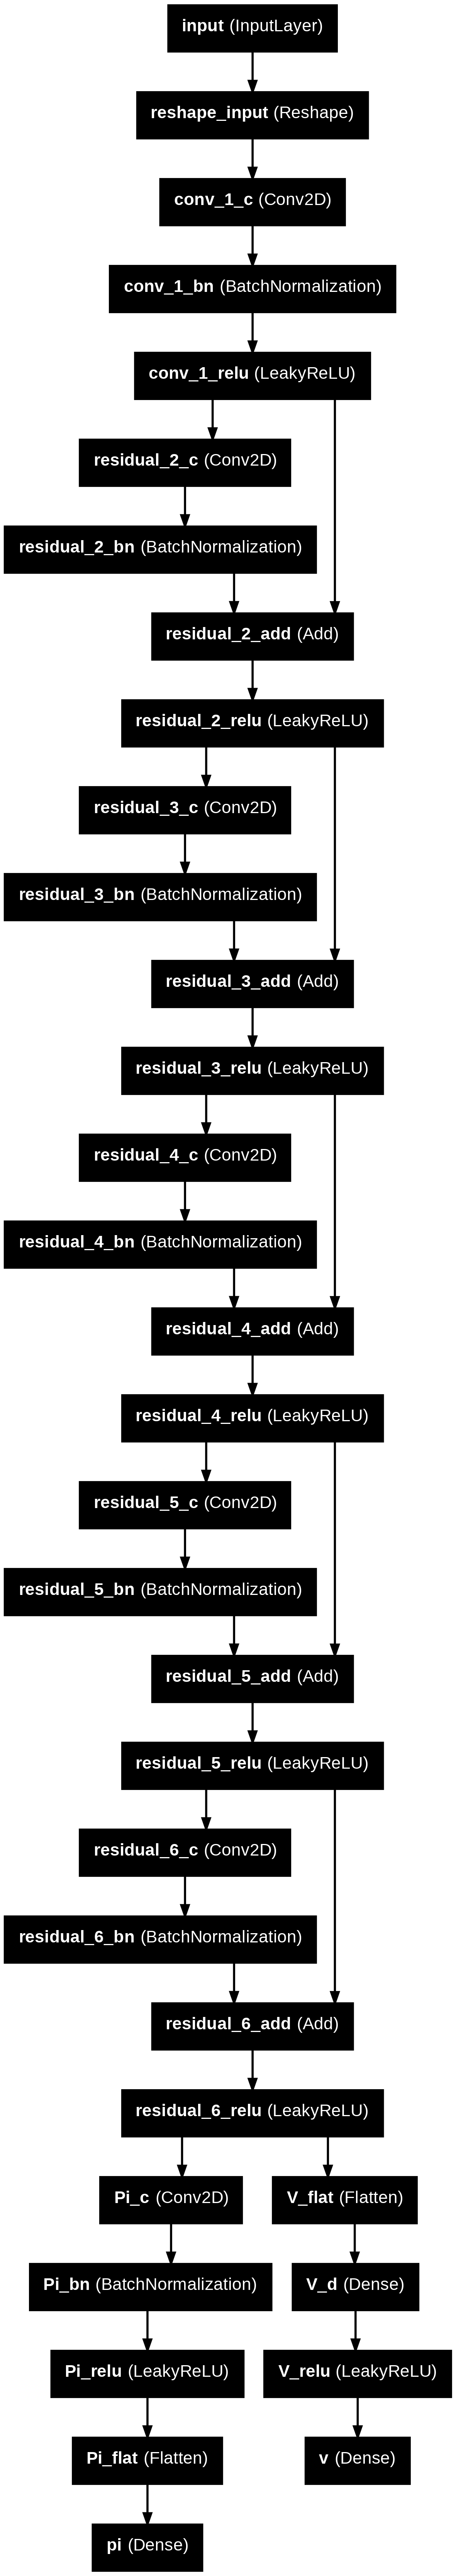

In [33]:
#@title Mostrar Red de AlphaZero

jugAZ.showModel()


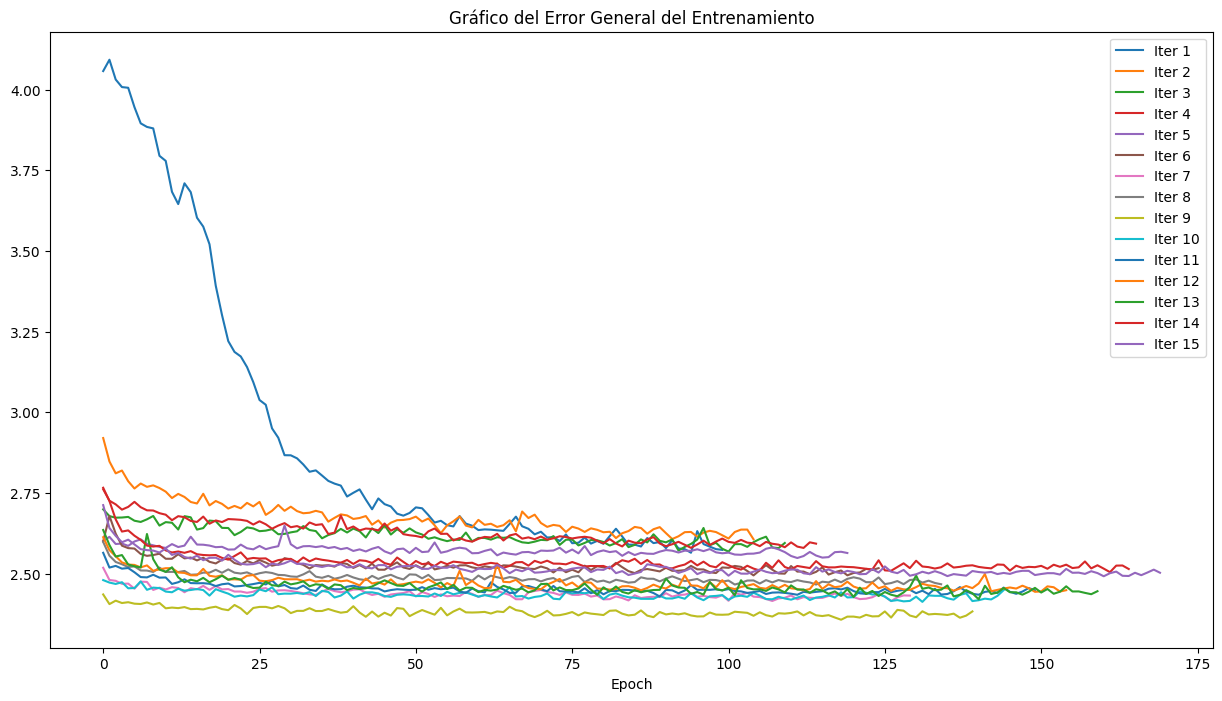

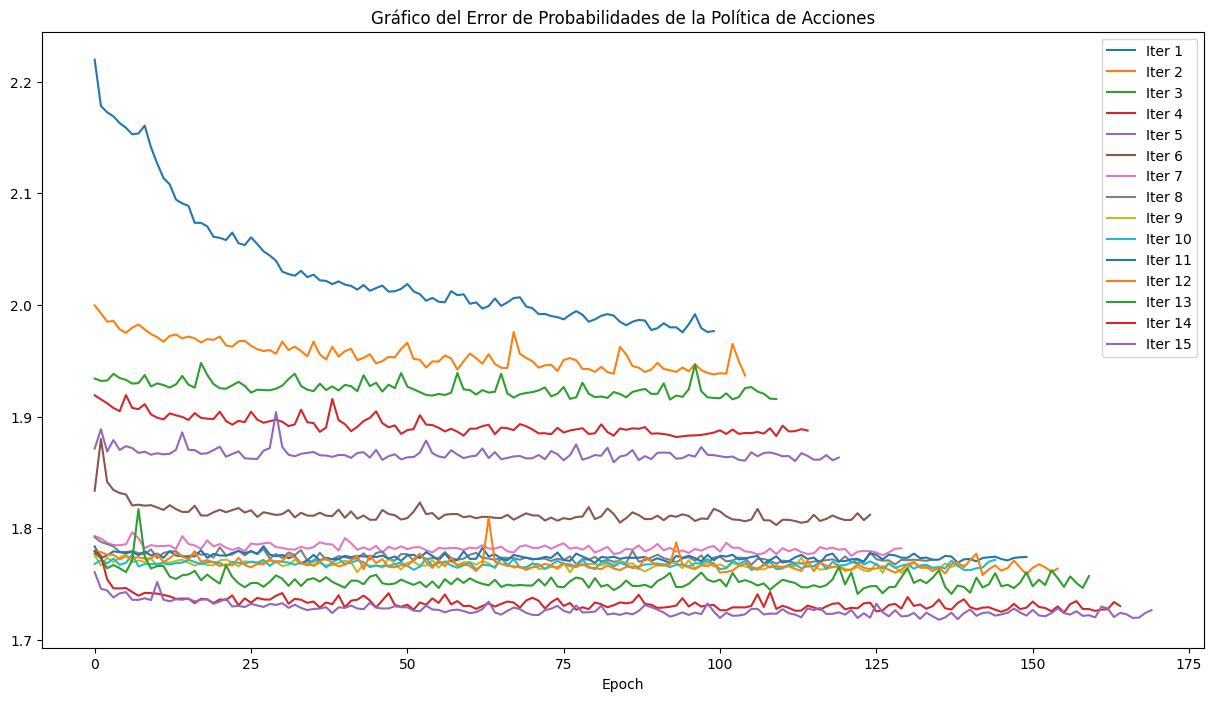

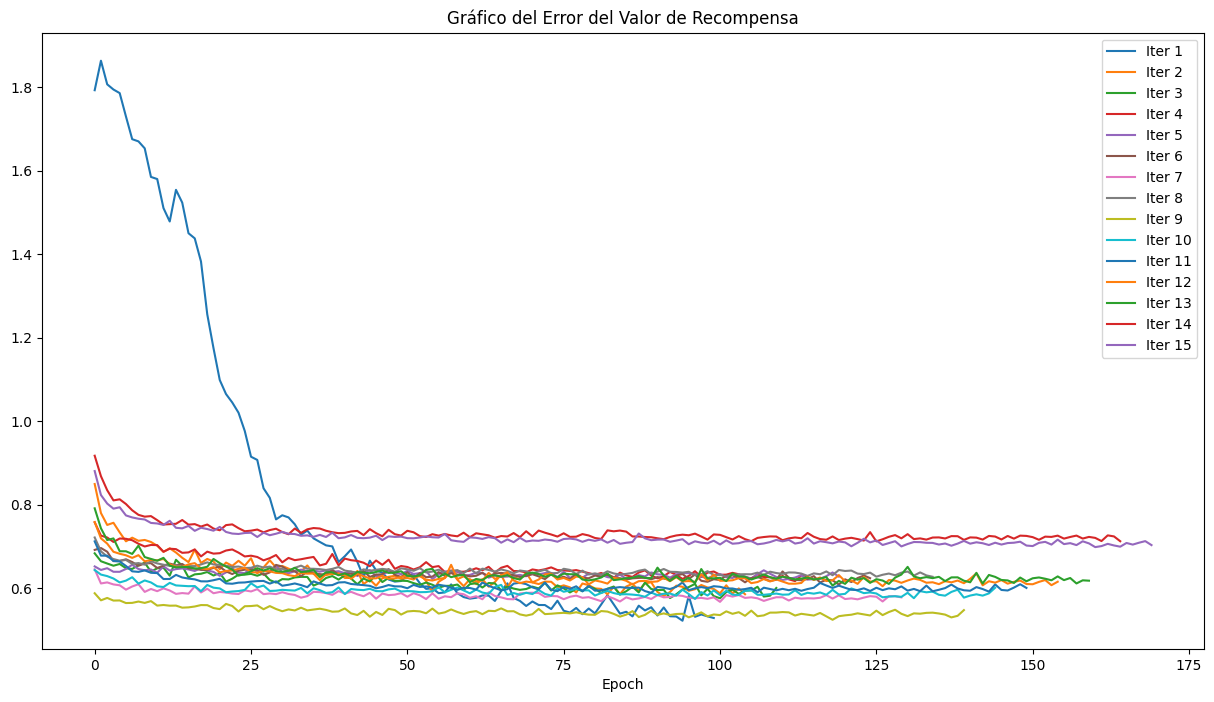

In [34]:
#@title Mostrar Gráficos del Entrenamiento

if entrenar:
  jugAZ.showTrainingDiagrams()
else:
  print("No se ha ejecutado el entrenamiento por lo que no ese puede mostrar el gráfico!")


In [35]:
#@title Probar el Agente Entrenado contra el Azar
cantidad_partidas_azar_probar = 100 #@param {type:"integer"}
mostrar_detalle_partidas_azar = False #@param {type:"boolean"}

# hacer jugar
print("\n> Probando el AlphaZero contra jugador al azar:")
ganaAZ, ganaRND, empateAZRND = CompetirAgentes(cantidad_partidas_azar_probar,
                                        ag1=jugAZ, ag2=randomAgent,
                                        descAg1="AlphaZero", descAg2="Azar",
                                        mostrar=True,
                                        mostrarResultadoJugadas=mostrar_detalle_partidas_azar)




> Probando el AlphaZero contra jugador al azar:


   Compiten Azar (X) vs AlphaZero (O): 100%|██████████| 50/50 [01:46<00:00,  2.12s/it]



 -- AlphaZero gana: 93.0 *
 -- Azar gana: 5.0 
 -- cantidad de empates: 2.0 




##Prueba de Modelo

In [37]:
#@title Cargar o Guardar el Modelo del Agente AZ

# parámetros
directorio_modelo = '/content/gdrive/MyDrive/IA/demoRL/Modelos/AZTaTeTi' #@param {type:"string"}
accion_realizar = "Grabar Modelo" #@param ["-", "Cargar Modelo", "Grabar Modelo"]

# define nombre de archivos a usar
archivo_nombre_red = directorio_modelo + "/AZnet.keras"
archivo_nombre_agente = directorio_modelo + "/AZagent.joblib"

if accion_realizar != "-":

  import joblib
  import os

  # Montar Drive
  from google.colab import drive
  drive.mount('/content/gdrive')

  if accion_realizar == "Grabar Modelo":
      # si no existe el directorio, lo crea
      if not os.path.isdir(directorio_modelo):
        os.makedirs(directorio_modelo)
      # guarda la red del agente entrenado
      jugAZ.net.save_model(directorio_modelo, archivo_nombre_red)
      print("- Modelo de Red de Agente AlphaZero grabado  en ",  archivo_nombre_red)
      # guarda las clases auxiliares del agente entrenado
      joblib.dump(jugAZ, archivo_nombre_agente)
      print("- Agente AlphaZero grabado en ",  archivo_nombre_agente)

  elif accion_realizar == "Cargar Modelo":
      # carga la política del modelo --- el resto no se necesita cargar
      if os.path.isfile(archivo_nombre_agente):
        # recupera agente AlphaZero
        jugAZ =  joblib.load(archivo_nombre_agente)
        print("- Agente AlphaZero recuperado de ",  archivo_nombre_agente)
      else:
        jugAZ = None
        print("- No se encuentra el archivo en ",  archivo_nombre_agente)


Mounted at /content/gdrive
  Modelo grabado en '/content/gdrive/MyDrive/IA/demoRL/Modelos/AZTaTeTi/AZnet.keras'
- Modelo de Red de Agente AlphaZero grabado  en  /content/gdrive/MyDrive/IA/demoRL/Modelos/AZTaTeTi/AZnet.keras
- Agente AlphaZero grabado en  /content/gdrive/MyDrive/IA/demoRL/Modelos/AZTaTeTi/AZagent.joblib


In [38]:
#@title Probar el Agente AlphaZero Entrenado contra otro Agente Alpha Zero
cantidad_partidas_agentes_probar = 100 #@param {type:"integer"}
competir_AZ_entrenado_contra = "AZ sin entrenar" #@param ["AZ entrenado", "AZ sin entrenar"]
mostrar_detalle_partidas_agentes = False #@param {type:"boolean"}

# define segundo jugador
auxCoach = AZcoachClass(envTraining, args)
jugAZ2 = auxCoach.inicialiceAZagent(False)
if competir_AZ_entrenado_contra == "AZ entrenado":
  # copia la red del entrenado en el segundo jugador
  # para que tenga la red entrenada
  jugAZ2.net = jugAZ.net
  desc2 = "AZ entrenado"
else:
  desc2 = "AZ sin entrenar"

# hacer jugar
print("\n> Probando el AlphaZero contra otro AlphaZero:")
ganaAZ1, ganaAZ2, empateAZ = CompetirAgentes(cantidad_partidas_azar_probar,
                                        ag1=jugAZ, ag2=jugAZ2,
                                        descAg1="AZ entrenado", descAg2=desc2,
                                        mostrar=True,
                                        mostrarResultadoJugadas=mostrar_detalle_partidas_agentes)




> Probando el AlphaZero contra otro AlphaZero:


   Compiten AZ sin entrenar (X) vs AZ entrenado (O): 100%|██████████| 50/50 [02:46<00:00,  3.34s/it]



 -- AZ entrenado gana: 54.0 *
 -- AZ sin entrenar gana: 46.0 
 -- cantidad de empates: 0.0 




In [39]:
#@title Probar el Agente Entrenado contra el Usuario (humano)

probarAgenteHumano = True #@param {type:"boolean"}

HumanoAg = None

if probarAgenteHumano:

    # hace jugar
    cont = True
    while cont:
        # simula jugada
        res = CompetirAgentes(1, humanoAgent, jugAZ, descAg1="Humano", descAg2="AlphaZero", mostrar=True, mostrarResultadoJugadas=True)
        # pregunta si hace nueva jugada
        print(" ")
        cont = (input("--¿Desea jugar nuevamente? (S/N)").upper() == "S")



**     Compiten Humano (X) vs AlphaZero (O): **
 Ini: 
      --------
     1|- - - |
     2|- - - |
     3|- - - |
      --------
       1 2 3 

Indique la coordenada para jugador X: 22
 #1: jugador X: (2, 2)
 #2: jugador O: (1, 1)
      --------
     1|O - - |
     2|- X - |
     3|- - - |
      --------
       1 2 3 

Indique la coordenada para jugador X: 13
 #3: jugador X: (1, 3)
 #4: jugador O: (3, 1)
      --------
     1|O - O |
     2|- X - |
     3|X - - |
      --------
       1 2 3 

Indique la coordenada para jugador X: 21
 #5: jugador X: (2, 1)
 #6: jugador O: (3, 3)
      --------
     1|O X O |
     2|- X - |
     3|X - O |
      --------
       1 2 3 

Indique la coordenada para jugador X: 23
 #7: jugador X: (2, 3)
 -Situación Final: 

      --------
     1|O X O |
     2|- X - |
     3|X X O |
      --------
       1 2 3 

    GANA jugador X



 -- Humano gana: 1.0 *
 -- AlphaZero gana: 0.0 
 -- cantidad de empates: 0.0 


 
--¿Desea jugar nuevamente? (S/N)s

**     Co